<a href="https://colab.research.google.com/github/Atiqah-Ayuni/IDS-website-PoliDS/blob/master/clasification_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Objectives

After completing this lab you will be able to:

*   Develop a various classification algorithms

In this lab exercise, you will learn a various classification machine learning algorithms. You will use the classification algorithms to build a model from the historical data of patients, and their response to different medications. Then you will use the trained decision tree to predict the class of an unknown patient, or to find a proper drug for a new patient.


<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="https://#about_dataset">About the dataset</a></li>
        <li><a href="https://#downloading_data">Downloading the Data</a></li>
        <li><a href="https://#pre-processing">Pre-processing</a></li>
        <li><a href="https://#setting_up_tree">Setting up the Decision Tree</a></li>
        <li><a href="https://#modeling">Modeling</a></li>
        <li><a href="https://#prediction">Prediction</a></li>
        <li><a href="https://#evaluation">Evaluation</a></li>
        <li><a href="https://#visualization">Visualization</a></li>
    </ol>
</div>
<br>
<hr>


Import the Following Libraries:

<ul>
    <li> <b>numpy as np</b> </li>
    <li> <b>pandas as pd</b> </li>
    <li> <b>matplotlib.pyplot as plt</b> </li>
    <li> <b>seaborn as sns</b> </li>
    <li> <b>train_test_split</b> from <b>sklearn.model_selection</b> </li>
    <li> <b>LabelEncoder or OneHotEncoder</b> (which ever you prefer) from <b>sklearn.preprocessing</b> </li>
    <li> <b>GausianNB</b> from <b>sklearn.naive_bayes</b> </li>
    <li> <b>metrics</b> from <b>sklearn.metrics</b> </li>

</ul>


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

<div id="about_dataset">
    <h2>About the dataset</h2>
    Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.
    <br>
    <br>
    Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.
    <br>
    <br>
    It is a sample of multiclass classifier, and you can use the training part of the dataset
    to build a decision tree, and then use it to predict the class of an unknown patient, or to prescribe a drug to a new patient.
    <br>
    Typical features in the dataset:
     <li>Age (numeric)
     <li>Sex (categorical: M, F)
     <li>BP (categorical: HIGH, NORMAL, LOW)
     <li>Cholesterol (categorical: HIGH, NORMAL)
     <li>Na_to_K (numeric: Sodium/Potassium ratio)
     <li>Drug (target label)
</div>


<div id="downloading_data">
    <h2>Load the Data</h2>
</div>

Now, load the data using pandas dataframe:


In [6]:
drug = pd.read_csv('drug200.csv')

NameError: name 'pd' is not defined

In [5]:
drug

NameError: name 'drug' is not defined

<div id="Explore the data">
    <h3>Explore the data</h3>
    What is the size of data?
    What is the data descriptive?
</div>


In [2]:
# write your code here
print("The dataset size is: ", drug.shape)
print("The dataset description is: ", drug.describe())

NameError: name 'drug' is not defined

<div href="pre-processing">
    <h2>Pre-processing</h2>
</div>


Using <b>my_data</b> as the Drug.csv data read by pandas, declare the following variables: <br>

<ul>
    <li> <b> X </b> as the <b> Feature Matrix </b> (data of my_data) </li>
    <li> <b> X </b> is 'Age', 'Sex_n', 'BP_n', 'Chol_n', 'Na_to_K'</li>
    <li> <b> Y </b> as the <b> response vector </b> (target) </li>
    <li> Y is 'Drug'</li>
</ul>


Remove the column containing the target name since it doesn't contain numeric values.


In [4]:
#split data into X and Y
X = drug[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']]
Y = drug['Drug']
print(X)
print(Y)

NameError: name 'drug' is not defined

As you may figure out, some features in this dataset are categorical, such as **Sex** or **BP**. Convert the categorical variable into dummy/indicator variables.


In [ ]:
#label encoder or OneHotEncoder for Sex, BP and Cholesterol
from sklearn.preprocessing import LabelEncoder

# Create a copy of X for encoding
X_encoded = X.copy()

# Encode categorical variables
le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_chol = LabelEncoder()

X_encoded['Sex'] = le_sex.fit_transform(X_encoded['Sex'])
X_encoded['BP'] = le_bp.fit_transform(X_encoded['BP'])
X_encoded['Cholesterol'] = le_chol.fit_transform(X_encoded['Cholesterol'])

print(X_encoded.values)

[[23 0 0 0 25.355]
 [47 1 1 0 13.093]
 [47 1 1 0 10.114]
 [28 0 2 0 7.798]
 [61 0 1 0 18.043]
 [22 0 2 0 8.607]
 [49 0 2 0 16.275]
 [41 1 1 0 11.037]
 [60 1 2 0 15.171]
 [43 1 1 1 19.368]
 [47 0 1 0 11.767]
 [34 0 0 1 19.199]
 [43 1 1 0 15.376]
 [74 0 1 0 20.942]
 [50 0 2 0 12.703]
 [16 0 0 1 15.516]
 [69 1 1 1 11.455]
 [43 1 0 0 13.972]
 [23 1 1 0 7.298]
 [32 0 0 1 25.974]
 [57 1 1 1 19.128]
 [63 1 2 0 25.917]
 [47 1 1 1 30.568]
 [48 0 1 0 15.036]
 [33 0 1 0 33.486]
 [28 0 0 1 18.809]
 [31 1 0 0 30.366]
 [49 0 2 1 9.381]
 [39 0 1 1 22.697]
 [45 1 1 0 17.951]
 [18 0 2 1 8.75]
 [74 1 0 0 9.567]
 [49 1 1 1 11.014]
 [65 0 0 1 31.876]
 [53 1 2 0 14.133]
 [46 1 2 1 7.285]
 [32 1 0 1 9.445]
 [39 1 1 1 13.938]
 [39 0 2 1 9.709]
 [15 1 2 0 9.084]
 [73 0 2 0 19.221]
 [58 0 0 1 14.239]
 [50 1 2 1 15.79]
 [23 1 2 0 12.26]
 [50 0 2 1 12.295]
 [66 0 2 1 8.107]
 [37 0 0 0 13.091]
 [68 1 1 0 10.291]
 [23 1 2 0 31.686]
 [28 0 1 0 19.796]
 [58 0 0 0 19.416]
 [67 1 2 1 10.898]
 [62 1 1 1 27.183]
 [24 0 

Print the target variable.


In [3]:
#print y
print(y)

NameError: name 'y' is not defined

<hr>

<div id="Model Setting">
    <h2>Setting up the Naive Bayes Algorithm</h2>
    We will be using <b>train/test split</b> on our algorithms </b>. Let's import <b>train_test_split</b> from <b>sklearn.model_selection</b>.
</div>


Now <b> train_test_split </b> will return 4 different parameters. We will name them:<br>
X_trainset, X_testset, Y_trainset, Y_testset <br> <br>
The <b> train_test_split </b> will need the parameters: <br>
X, y, test_size=0.3, and random_state=3. <br> <br>
The <b>X</b> and <b>y</b> are the arrays required before the split, the <b>test_size</b> represents the ratio of the testing dataset, and the <b>random_state</b> ensures that the dataset were split at random with consistent shuffle.


In [ ]:
#write your code here
X_trainset, X_testset, Y_trainset, Y_testset = train_test_split(X_encoded, Y, test_size=0.3, random_state=3)

NameError: name 'X' is not defined

Print the shape of X_trainset and y_trainset. Ensure that the dimensions match the prior splitting request.


In [ ]:
print('Shape of X training set {}'.format(X_trainset.shape),'&',' Size of Y training set {}'.format(Y_trainset.shape))


Shape of X training set (140, 5) &  Size of Y training set (140,)



Print the shape of X_testset and y_testset.


In [ ]:
# your code
print('Shape of X training set {}'.format(X_testset.shape),'&',' Size of Y training set {}'.format(Y_testset.shape))


Shape of X training set (60, 5) &  Size of Y training set (60,)


<hr>

<div id="modeling">
    <h2>Modeling</h2>
    Lets create an instance of the <b>Naive Bayes</b>.

</div>


In [ ]:
# Create a Naive Bayes classifier and name it as Model_NB1

Model_NB1 = GaussianNB()

Next, we will fit the data with the training feature matrix <b> X_trainset </b> and training  response vector <b> y_trainset </b>


In [ ]:
# Train the classifier with X_trainset and Y_trainset

Model_NB1.fit(X_trainset, Y_trainset)

GaussianNB()

<hr>

<div id="prediction">
    <h2>Prediction</h2>
    Let's make some <b>predictions</b> on the testing dataset and store it into a variable called <b>predNB1</b>.
</div>


In [ ]:
#make prediction for Model_NB1 (Naive Bayes)

predNB1 = Model_NB1.predict(X_testset)

You can print out <b>predNB1</b> and <b>y_testset</b> if you want to visually compare the predictions to the actual values.





In [ ]:
#Compare the predicted Y for Model_NB1 vs Actual Y Test

print(predNB1)
print(Y_testset)

['drugY' 'drugX' 'drugX' 'drugX' 'drugX' 'drugC' 'drugA' 'drugA' 'drugB'
 'drugA' 'drugY' 'drugA' 'drugY' 'drugY' 'drugX' 'drugY' 'drugX' 'drugX'
 'drugB' 'drugX' 'drugX' 'drugB' 'drugC' 'drugY' 'drugX' 'drugB' 'drugY'
 'drugY' 'drugA' 'drugX' 'drugB' 'drugC' 'drugC' 'drugX' 'drugX' 'drugC'
 'drugC' 'drugX' 'drugX' 'drugX' 'drugA' 'drugA' 'drugC' 'drugA' 'drugA'
 'drugY' 'drugY' 'drugY' 'drugC' 'drugY' 'drugB' 'drugX' 'drugY' 'drugX'
 'drugY' 'drugB' 'drugA' 'drugX' 'drugY' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
82     drugC
183    drugY
46     drugA
70     drugB
100    drugA
179    drugY
83     drugA
25     drugY
190    drugY
159    drugX
173    drugY
95     drugX
3      drugX
41     drugB
58     drugX
14     drugX
143    drugY
12     drugY
6      drugY
182    drugX
161    drugB
128    drugY
122    drugY
101    drugA
86     drugX
64     drugB
47     drugC
158    drugC
34     drugX
38     drugX
196    drugC
4      drugY
72     drugX
67     drugX
145  

<hr>

<div id="evaluation">
    <h2>Evaluation</h2>
    Next, let's check the accuracy of our model.
</div>


In [ ]:
#check the confusion matrix

conf = confusion_matrix(Y_testset, predNB1, )
print(conf)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 3  2  3  0 14]]


In [ ]:
#check the accuracy

acc = accuracy_score(Y_testset, predNB1)
print(acc)

0.85


In [ ]:
#check the classification report

report = classification_report(Y_testset, predNB1)
print(report)

              precision    recall  f1-score   support

       drugA       0.70      1.00      0.82         7
       drugB       0.71      1.00      0.83         5
       drugC       0.62      1.00      0.77         5
       drugX       1.00      0.95      0.98        21
       drugY       0.93      0.64      0.76        22

    accuracy                           0.85        60
   macro avg       0.79      0.92      0.83        60
weighted avg       0.89      0.85      0.85        60



**Accuracy classification score** computes subset accuracy: the set of labels predicted for a sample must exactly match the corresponding set of labels in y_true.

In multilabel classification, the function returns the subset accuracy. If the entire set of predicted labels for a sample strictly matches with the true set of labels, then the subset accuracy is 1.0; otherwise it is 0.0.


<hr>

<div id="visualization">
    <h2>Visualization</h2>

Let's visualize Confusion Matrix using heatmap.

</div>


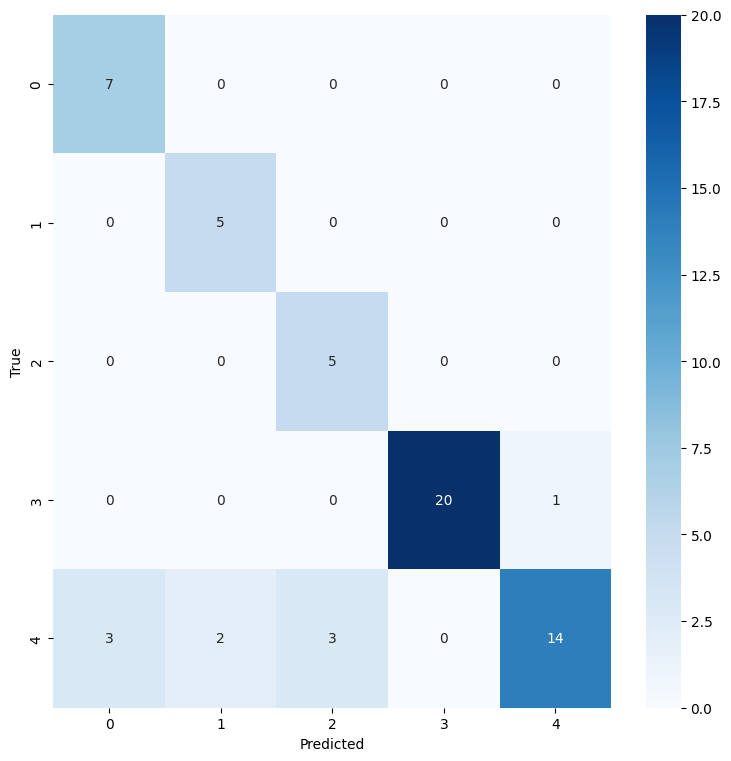

In [ ]:
#heatmap for confusion matrix

plt.figure(figsize=(9,9))
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



# Another variant of Naive Bayes

In [ ]:
# try to set the parameter such as var_smoothing or alpha in the models
# let try using another variant of naive bayes such as Multinomial and Bernoulli
# split the data using cross validation technique
# compare the performance of each models

In [ ]:
#make prediction for Model_NB2 (Multinomial Naive Bayes)


[[ 4  0  0  0  3]
 [ 1  4  0  0  0]
 [ 0  0  0  4  1]
 [ 0  0  0 15  6]
 [ 4  1  2  5 10]]
0.55


In [ ]:
#make prediction for Model_NB3 (Categorical Naive Bayes)


[[ 1  4  0  0  2]
 [ 1  2  0  0  2]
 [ 0  0  3  2  0]
 [ 0  0  0 21  0]
 [ 0  0  0  0 22]]
0.8166666666666667


In [ ]:
#make prediction for Model_NB5 (Gaussian Naive Bayes) with alpha


[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  1  2  0 19]]
0.9333333333333333


# Logistic Regression

Another variant of Logistic Regression

# Decison Tree

Another variant of Decision Tree

# Random Forest

# KNN

# Support Vector Machine (Classification)

Another variant of SVC

Explain your findings